# Pichler et al. (2022) Dynamic Input-Output Model (PichlerEtAl2022DIO)

This model implements the dynamic disequilibrium input-output model
introduced by Pichler, Pangallo, del Rio-Chanona, Lafond & Farmer (2022),
*Forecasting the propagation of pandemic shocks with a dynamic
input-output model*, Journal of Economic Dynamics and Control, 144,
104527.  The model simulates daily production, consumption, and
employment dynamics across an input-output network subject to supply
and demand shocks.  Key features:

- **Partially Binding Leontief (PBL) production functions** that
  distinguish critical from non-critical intermediate inputs.
- **Industry-specific inventories** with target stock levels.
- **Muellbauer consumption function** incorporating fear-of-infection
  and permanent-income effects.
- **Sluggish labour adjustment** with asymmetric hiring/firing speeds.

## Module Contents

As with all `MacroStat` models, PichlerEtAl2022DIO is divided into
Variables, Parameters, Scenarios, and the Behavior (model
initialisation and steps).  The module-level documentation can be
found in:

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <variables.rst>
    Parameters <parameters.rst>
    Equations <equations.rst>
    Scenarios <scenarios.rst>
```

## Model Overview

A time step corresponds to one calendar day.  The economy initially
rests in a steady state until exogenous shocks are applied.  Every day
the model executes the following steps:

1. **Labour adjustment** -- firms hire or fire workers depending on
   whether their workforce was insufficient or redundant.
2. **Demand** -- households decide consumption; industries place
   intermediate-goods orders.
3. **Production** -- industries produce subject to labour capacity,
   input availability, and demand constraints.
4. **Rationing** -- if output < demand, production is distributed
   pro rata across customers.
5. **Inventories & accounting** -- inventory levels are updated;
   profits and savings are computed.

### Key Equations

The output identity decomposes sector $i$'s gross output into
intermediate use by all sectors, household consumption, and other
final demand:

$$
x_{i,t} = \sum_{j=1}^{N} Z_{ij,t} + c_{i,t} + f_{i,t}
$$

Sector $i$ produces the minimum of its labour capacity, its
input-availability capacity, and realised demand:

$$
x_{i,t} = \min\{x^{\text{cap}}_{i,t},\; x^{\text{inp}}_{i,t},\; d_{i,t}\}
$$

Labour adjusts toward the required workforce with asymmetric hiring
and firing speeds:

$$
l_{i,t} = l_{i,t-1} + \gamma\,\frac{l_{i,0}}{x_{i,0}}
  \left[\min\{x^{\text{inp}}_{i,t},\, d_{i,t}\} - x^{\text{cap}}_{i,t}\right]
$$

See the [Equations](equations.rst) page for the complete behavioral
system.

## Simplified 3-sector example

This section runs the model out of the box with its illustrative
three-sector default (sectors A, B, C).  The model code is identical
to the 55-sector case; only the parameter source differs.  Run the
notebook from the project venv kernel (e.g. `uv run jupyter lab`).

In [1]:
%load_ext autoreload
%autoreload 2
import importlib
import logging
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from macrostat.models.PichlerEtAl2022DIO import (
    ParametersPichlerEtAl2022DIO,
    PichlerEtAl2022DIO,
    ScenariosPichlerEtAl2022DIO,
)

plt.style.use("../../macrostat.mplstyle")
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

Instantiate with the zero-config default and simulate the baseline
182-day trajectory.  No shock is applied, so the economy stays at
its initial steady state.

In [2]:
model = PichlerEtAl2022DIO()
baseline = model.simulate()["GrossOutput"].detach().cpu().numpy()

Baseline sectoral output -- the system is initialised at a closed
input-output equilibrium, so $x_t = x_0$ for all $t$.

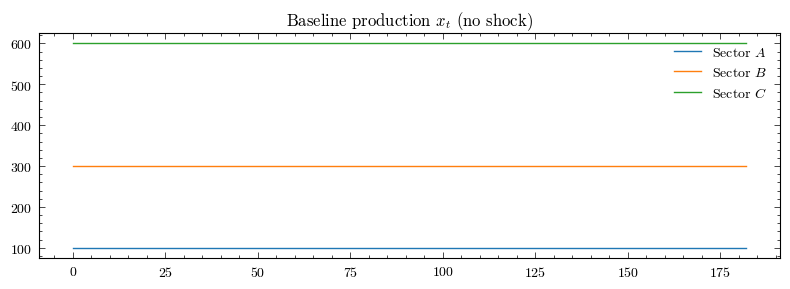

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
for j, name in enumerate(["A", "B", "C"]):
    ax.plot(baseline[:, j], label=rf"Sector ${name}$")
ax.set_title(r"Baseline production $x_t$ (no shock)")
ax.legend()
plt.tight_layout()
plt.show()

Apply a 50% supply shock to sector A for 30 days starting on day 10
and re-simulate.  Sector A's output drops directly; sectors B and C
fall through the essential-input chain $A \to B \to C$.

In [4]:
shock = {"SupplyShock": torch.zeros(model.parameters.hyper["timesteps"], 3)}
shock["SupplyShock"][10:40, 0] = 0.5
model.scenarios.add_vector_scenario(shock, name="UpstreamShock")
shocked = model.simulate(scenario=1)["GrossOutput"].detach().cpu().numpy()

Side-by-side comparison: baseline (grey) vs upstream shock (red).
Sector A absorbs the shock immediately; the propagation to B and C
is mediated by the inventory buffer and the essential-input mask.

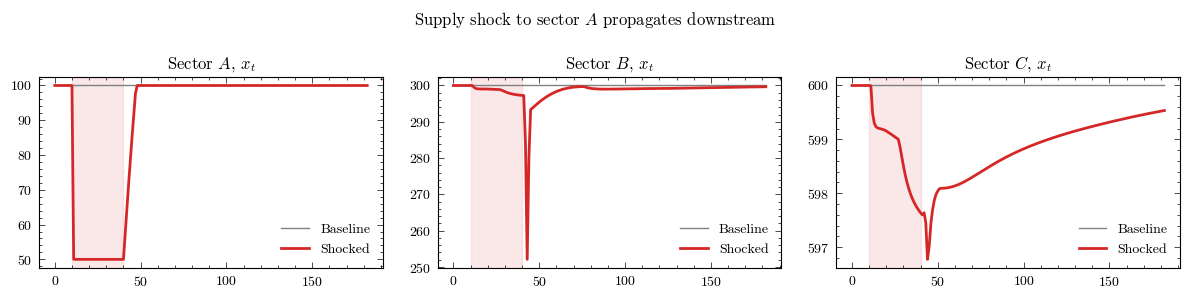

In [5]:
fig, axs = plt.subplots(ncols=3, figsize=(12, 3))
for j, (ax, name) in enumerate(zip(axs, ["A", "B", "C"])):
    ax.plot(baseline[:, j], color="grey", linewidth=1, label="Baseline")
    ax.plot(shocked[:, j], color="tab:red", linewidth=2, label="Shocked")
    ax.axvspan(10, 40, color="tab:red", alpha=0.1)
    ax.set_title(rf"Sector ${name}$, $x_t$")
    ax.legend()
fig.suptitle(r"Supply shock to sector $A$ propagates downstream")
plt.tight_layout()
plt.show()

## Replicating the paper's results using data

The Pichler et al. (2022) calibration uses the WIOD UK 2014 55-sector
input-output table, the IHS Markit critical-input matrix, and ONS
inventory-target ratios.  Neither WIOD nor IHS Markit can be
redistributed inside this package; users must obtain them under their
own licence terms.

**The cells below execute only when the `PICHLER2022_DATA_DIR`
environment variable points to a replication directory; otherwise
they no-op and the rendered public docs show no output for this
section.**  Set the variable to the parent of `data/` and re-run.

### Data sources

Layout expected by `from_wiod_uk`:

```
$PICHLER2022_DATA_DIR/
└── data/
    ├── io_data_detail/
    │   ├── GBR_A.csv              # WIOD 55-sector A matrix
    │   ├── GBR_Z.csv              # intermediate consumption Z
    │   ├── GBR_x.csv              # initial gross output
    │   ├── GBR_lab.csv            # labour compensation
    │   ├── GBR_cap.csv            # capital / profits
    │   ├── GBR_f.csv              # final demand
    │   ├── GBR_f_imported.csv     # imported final demand
    │   ├── GBR_consumer_taxes.csv
    │   ├── GBR_firm_taxes.csv
    │   ├── GBR_other_expenses.csv
    │   └── GBR_Z_imports.csv
    ├── IHS_matrices_processed/
    │   └── A.essential2.csv       # IHS Markit critical-input mask
    ├── ons_table_ratio_inv_go.csv # ONS inventory-target days
    └── shocks/
        └── shock_scenarios.csv    # pandemic supply-shock series
```

- **WIOD 2016 release (2014 reference year)**: as of 2026 the canonical
  project page redirects intermittently; the FIGARO release from
  Eurostat is a successor product with comparable structure.
- **IHS Markit critical-input matrix**: published as supplementary
  material with Pichler et al. (2022); check the journal's
  replication archive on Zenodo.
- **ONS inventory ratios**: ONS public release.

In [6]:
DATA_ROOT = os.environ.get("PICHLER2022_DATA_DIR")
HAS_DATA = DATA_ROOT is not None and Path(DATA_ROOT).is_dir()

Construct the 55-sector calibration from CSV and attach the paper's
pandemic shock scenario.  Skipped when `PICHLER2022_DATA_DIR` is
unset.

In [7]:
if HAS_DATA:
    data_dir = Path(DATA_ROOT) / "data" / "io_data_detail"
    ihs_dir = Path(DATA_ROOT) / "data" / "IHS_matrices_processed"
    inv_file = Path(DATA_ROOT) / "data" / "ons_table_ratio_inv_go.csv"
    shock_csv = Path(DATA_ROOT) / "data" / "shocks" / "shock_scenarios.csv"
    fd_csv = data_dir / "GBR_f.csv"

    params = ParametersPichlerEtAl2022DIO.from_wiod_uk(
        data_dir=data_dir, ihs_dir=ihs_dir, inv_file=inv_file
    )
    scenarios = ScenariosPichlerEtAl2022DIO.from_shocks_csv(
        parameters=params, shock_csv=shock_csv, final_demand_csv=fd_csv
    )
    full_model = PichlerEtAl2022DIO(parameters=params, scenarios=scenarios)
    baseline_full = (
        full_model.simulate(scenario=0)["GrossOutput"].detach().cpu().numpy()
    )
    shocked_full = full_model.simulate(scenario=1)["GrossOutput"].detach().cpu().numpy()

Aggregate gross output, baseline vs pandemic shock, normalised to
pre-shock levels.  Reproduces the qualitative shape of Pichler et al.
(2022) Figure 4.

In [8]:
if HAS_DATA:
    agg_baseline = baseline_full.sum(axis=1)
    agg_shocked = shocked_full.sum(axis=1)
    norm = agg_baseline[0]
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(agg_baseline / norm, color="grey", linewidth=1, label="Baseline")
    ax.plot(agg_shocked / norm, color="tab:red", linewidth=2, label="Pandemic shock")
    ax.set_title(r"Aggregate output, half-critical PBL, WIOD UK 2014")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Source

Pichler, A., Pangallo, M., del Rio-Chanona, R.M., Lafond, F. & Farmer,
J.D. (2022).  Forecasting the propagation of pandemic shocks with a
dynamic input-output model.  *Journal of Economic Dynamics and
Control*, 144, 104527.
[https://doi.org/10.1016/j.jedc.2022.104527](https://doi.org/10.1016/j.jedc.2022.104527)